In [1]:
import os
import glob

import ants

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import nibabel as nib

import SimpleITK as sitk

from skimage.transform import resize

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [4]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:
        nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


### Register and preprocess the final healthy flair dataset
HCP-YA\
Dallas Lifespan Brain Study\
AINI-Stroke AIT

In [ ]:
template_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/mni_icbm152_t2_tal_nlin_sym_09a_extracted_brain.nii.gz"
template_img = nib.load(template_path)
template_data = template_img.get_fdata()
print(template_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(template_data[template_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(template_data[:, template_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(template_data[:, :, template_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Pad and resize the template to (128,128,128)

In [ ]:
original_shape = template_data.shape

# Calculate padding for each dimension
pad_width = []
for orig, target in zip(original_shape, (233, 233, 233)):
    total_pad = max(target - orig, 0)
    before = total_pad // 2
    after = total_pad - before
    pad_width.append((before, after))

# Pad the image
template_data = np.pad(template_data, pad_width, mode='constant', constant_values=0)

# Resize to (128, 128, 128)
template_data = resize(template_data, (128, 128, 128), anti_aliasing=True)

# Save the padded and resized image
padded_template_img = nib.Nifti1Image(template_data, template_img.affine, template_img.header)
output_template_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_FINAL_mni_icbm152_t2_tal_nlin_sym_09a_extracted_brain_padded_resized.nii.gz"
nib.save(padded_template_img, output_template_path)

In [ ]:
template_final = nib.load(output_template_path)
template_final_data = template_final.get_fdata()
print("Final template")
print(template_final_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(template_final_data[template_final_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(template_final_data[:, template_final_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(template_final_data[:, :, template_final_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")


## Dallas Lifespan Brain Study
Original Size: (512, 512, 24) & (512, 512, 64)\
1. Resample it to 1mm3
2. pad it to (230, 230, 230)
3. Resize to (128, 128, 128)
4. Orient it like MNI
5. Register it to histogram matched MNI

In [5]:
dallas_flair_unprocessed_folder = ROOT_DIR+"datasets/dallas_flair_extracted_brain/"
dallas_flair_resized_folder = ROOT_DIR+"datasets/dallas_flair_resized/"
os.makedirs(dallas_flair_resized_folder, exist_ok=True)

dallas_flair_final_output_folder_registered = ROOT_DIR+"datasets/final_flair_dataset_small/dallas_registered/"
os.makedirs(dallas_flair_final_output_folder_registered, exist_ok=True)

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [9]:
for image_path in tqdm(glob.glob(os.path.join(dallas_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(dallas_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 723/723 [21:15<00:00,  1.76s/it]


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [14]:
# pad to (224, 224, 224) and resize to (128, 128, 128)
os.makedirs(dallas_flair_resized_folder, exist_ok=True)

nifti_files = sorted(glob.glob(os.path.join(dallas_flair_resized_folder, "*.nii.gz")))
os.makedirs(dallas_flair_resized_folder, exist_ok=True)

for file_path in tqdm(nifti_files):
    out_path = os.path.join(dallas_flair_resized_folder, os.path.basename(file_path))
    if True: #not os.path.exists(out_path):
        img = nib.load(file_path)
        data = img.get_fdata()
        
        original_shape = data.shape

        # Calculate padding for each dimension
        pad_width = []
        for orig, target in zip(original_shape, (230, 230, 230)):
            total_pad = max(target - orig, 0)
            before = total_pad // 2
            after = total_pad - before
            pad_width.append((before, after))

        # Pad the image
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

        data = resize(data, (128, 128, 128), anti_aliasing=True)

        # Save padded image
        padded_img = nib.Nifti1Image(data, img.affine, img.header)
        
        nib.save(padded_img, out_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 723/723 [11:33<00:00,  1.04it/s]


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [16]:
template_before_hist_match = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_FINAL_mni_icbm152_t2_tal_nlin_sym_09a_extracted_brain_padded_resized.nii.gz"

# Load the first Dallas FLAIR image as the target for histogram matching
dallas_files = sorted(glob.glob(os.path.join(dallas_flair_resized_folder, "*.nii.gz")))
target_img = nib.load(dallas_files[0])
target_data = target_img.get_fdata()

# Load the template image to modify
template_img = nib.load(template_before_hist_match)
template_data = template_img.get_fdata()

# Perform histogram matching using ANTs
template_ants = ants.from_numpy(template_data)
target_ants = ants.from_numpy(target_data)

# Apply histogram matching
hist_matched = ants.histogram_match_image(template_ants, target_ants)

# Save the histogram matched template
hist_matched_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz"
hist_matched_img = nib.Nifti1Image(hist_matched.numpy(), template_img.affine, template_img.header)
nib.save(hist_matched_img, hist_matched_path)

print(f"Histogram matched template saved to: {hist_matched_path}")

Histogram matched template saved to: /home/fehrdelt/bettik/datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz


In [ ]:
# Load and plot the histogram matched template
hist_matched_template = nib.load(hist_matched_path)
hist_matched_data = hist_matched_template.get_fdata()

print(f"Histogram matched template shape: {hist_matched_data.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sagittal slice
axes[0].imshow(hist_matched_data[hist_matched_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Histogram Matched Template - Sagittal")
axes[0].axis("off")

# Coronal slice
axes[1].imshow(hist_matched_data[:, hist_matched_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Histogram Matched Template - Coronal")
axes[1].axis("off")

# Axial slice
axes[2].imshow(hist_matched_data[:, :, hist_matched_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Histogram Matched Template - Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [29]:

register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz", 
                     dataset_path=dallas_flair_resized_folder, 
                     output_path=dallas_flair_final_output_folder_registered)

nifti_files ['/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1003_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1003_ses-wave2_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1003_ses-wave3_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1007_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1007_ses-wave2_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1007_ses-wave3_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1008_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1008_ses-wave2_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1011_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz', '/home/fehrdelt/bettik/datasets/dallas_flair_resized/sub-1013_ses-wave1_acq-FL

  0%|                                                                                                                                             | 0/723 [00:00<?, ?it/s]

skipped registration already done
skipped registration already done
skipped registration already done
skipped registration already done
skipped registration already done


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 723/723 [18:48<00:00,  1.56s/it]


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(dallas_flair_final_output_folder_registered, "*.nii.gz")))[:50]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(50, 3, figsize=(10, 150))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    #print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## ISLES-2022 FLAIR
Original Size: (281, 352, 352)\
1. no resampling since they already have isotropic resolution (2, 2, 2)
2. PAD to (352, 352, 352)
3. Resize to (128, 128, 128)
4. Register it to histogram matched MNI

In [46]:
isles_flair_unprocessed_folder = ROOT_DIR+"/datasets/isles_flair/"
isles_masks_unprocessed_folder = ROOT_DIR+"/datasets/ISLES_masks/"

isles_flair_resized_folder = ROOT_DIR+"/datasets/ISLES_FLAIR_resized/"
isles_masks_resized_folder = ROOT_DIR+"/datasets/ISLES_masks_resized/"

isles_flair_final_output_folder_registered = ROOT_DIR+"/datasets/final_flair_dataset_small/isles_registered/"
ISLES_masks_final_output_folder_registered = ROOT_DIR+"/datasets/final_flair_dataset_small/ISLES_masks_registered/"

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(isles_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [36]:
os.makedirs(isles_flair_resized_folder, exist_ok=True)

for image_path in tqdm(glob.glob(os.path.join(isles_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(isles_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [13:20<00:00,  3.20s/it]


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(isles_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [38]:
# images
for image_path in tqdm(glob.glob(os.path.join(isles_flair_resized_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)

    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (250, 250, 250)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(isles_flair_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [11:45<00:00,  2.82s/it]


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(isles_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [41]:
# images and masks
register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz", 
                    dataset_path=isles_flair_resized_folder, 
                    output_path=isles_flair_final_output_folder_registered,
                    register_masks=False,
                    )


nifti_files ['/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0001_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0002_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0003_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0004_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0005_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0006_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0007_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0008_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0009_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/ISLES_FLAIR_resized/sub-strokecase0010_ses-0001_FLAIR.nii.gz', '/home/fehrdelt/bettik//dat

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [14:43<00:00,  3.53s/it]


In [ ]:
# Get the first 10 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(isles_flair_final_output_folder_registered, "*.nii.gz")))[:10]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(10, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].axis("off")

    if i==0:
        axes[i, 0].set_title(f"Image {i+1} - Sagittal")
        axes[i, 1].set_title(f"Image {i+1} - Coronal")
        axes[i, 2].set_title(f"Image {i+1} - Axial")

plt.tight_layout()
plt.show()

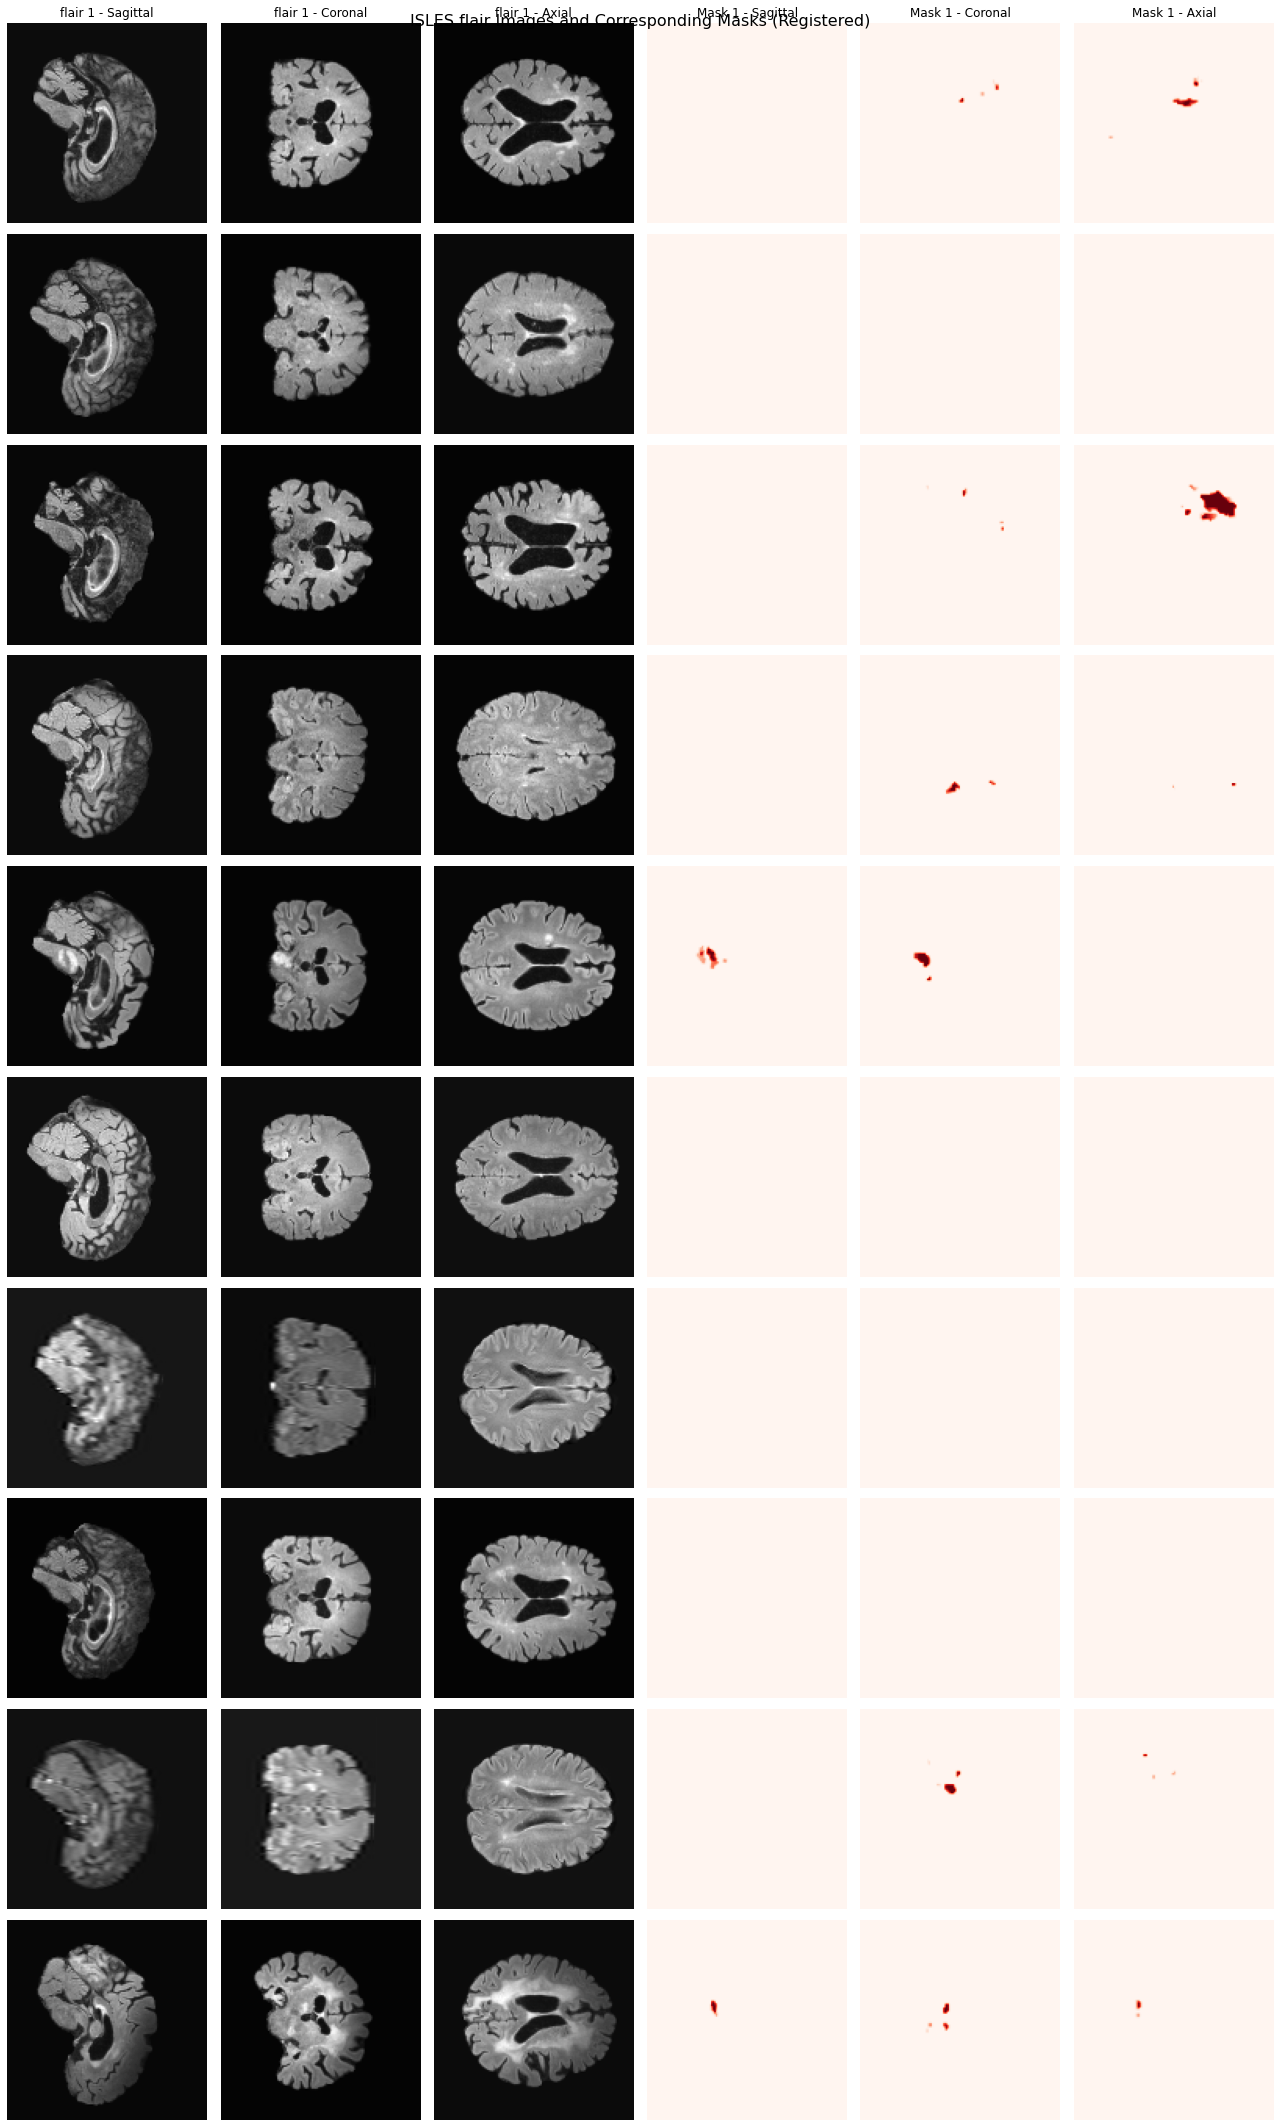

In [49]:
# Get sorted file paths for both flair images and masks
flair_paths = sorted(glob.glob(os.path.join(isles_flair_final_output_folder_registered, "*.nii.gz")))
mask_paths = sorted(glob.glob(os.path.join(ISLES_masks_final_output_folder_registered, "*.nii.gz")))

# Take first 10 pairs for visualization
num_pairs = min(10, len(flair_paths), len(mask_paths))

fig, axes = plt.subplots(num_pairs, 6, figsize=(18, 3*num_pairs))
plt.suptitle("ISLES flair Images and Corresponding Masks (Registered)", fontsize=16)

for i in range(num_pairs):
    # Load flair image and mask
    flair_img = nib.load(flair_paths[i]).get_fdata()
    mask_img = nib.load(mask_paths[i]).get_fdata()
    
    # Get middle slices
    mid_slice = flair_img.shape[2] // 2
    flair_axial = flair_img[:, :, mid_slice]
    mask_axial = mask_img[:, :, mid_slice]
    
    mid_slice_sag = flair_img.shape[0] // 2
    flair_sagittal = flair_img[mid_slice_sag, :, :]
    mask_sagittal = mask_img[mid_slice_sag, :, :]
    
    mid_slice_cor = flair_img.shape[1] // 2
    flair_coronal = flair_img[:, mid_slice_cor, :]
    mask_coronal = mask_img[:, mid_slice_cor, :]
    
    # Plot flair sagittal
    axes[i, 0].imshow(flair_sagittal, cmap="gray")
    axes[i, 0].set_title(f"flair {i+1} - Sagittal" if i == 0 else "")
    axes[i, 0].axis("off")
    
    # Plot flair coronal
    axes[i, 1].imshow(flair_coronal, cmap="gray")
    axes[i, 1].set_title(f"flair {i+1} - Coronal" if i == 0 else "")
    axes[i, 1].axis("off")
    
    # Plot flair axial
    axes[i, 2].imshow(flair_axial, cmap="gray")
    axes[i, 2].set_title(f"flair {i+1} - Axial" if i == 0 else "")
    axes[i, 2].axis("off")
    
    # Plot Mask sagittal
    axes[i, 3].imshow(mask_sagittal, cmap="Reds")
    axes[i, 3].set_title(f"Mask {i+1} - Sagittal" if i == 0 else "")
    axes[i, 3].axis("off")
    
    # Plot Mask coronal
    axes[i, 4].imshow(mask_coronal, cmap="Reds")
    axes[i, 4].set_title(f"Mask {i+1} - Coronal" if i == 0 else "")
    axes[i, 4].axis("off")
    
    # Plot Mask axial
    axes[i, 5].imshow(mask_axial, cmap="Reds")
    axes[i, 5].set_title(f"Mask {i+1} - Axial" if i == 0 else "")
    axes[i, 5].axis("off")

plt.tight_layout()
plt.show()

## LEMON FLAIR
Original Size: (384, 512, 28)\
1. Resample it to 1mm3
Pad
2. Resize to (128, 128, 128)
3. Register it to histogram matched MNI

In [20]:
lemon_flair_unprocessed_folder = ROOT_DIR+"/datasets/lemon_flair_extracted_brain/"
os.makedirs(lemon_flair_unprocessed_folder, exist_ok=True)

lemon_flair_resized_folder = ROOT_DIR+"/datasets/lemon_flair_resized/"
os.makedirs(lemon_flair_resized_folder, exist_ok=True)

lemon_flair_registered = ROOT_DIR+"/datasets/final_flair_dataset_small/lemon_registered/"
os.makedirs(lemon_flair_resized_folder, exist_ok=True)

Image 1 shape: (384, 512, 28)
Image 2 shape: (384, 512, 28)
Image 3 shape: (384, 512, 28)
Image 4 shape: (192, 512, 512)


<Figure size 432x288 with 0 Axes>

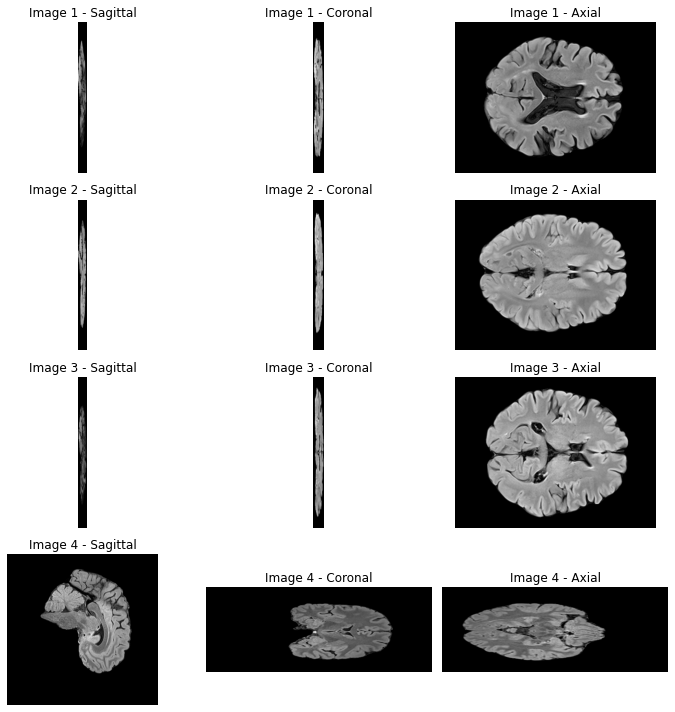

In [5]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(lemon_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# resample to 1mm3

for image_path in tqdm(glob.glob(os.path.join(lemon_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(lemon_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [08:10<00:00,  2.18s/it]


Image 1 shape: (165, 220, 140)
Image 2 shape: (165, 220, 140)
Image 3 shape: (165, 220, 140)
Image 4 shape: (192, 250, 250)


<Figure size 432x288 with 0 Axes>

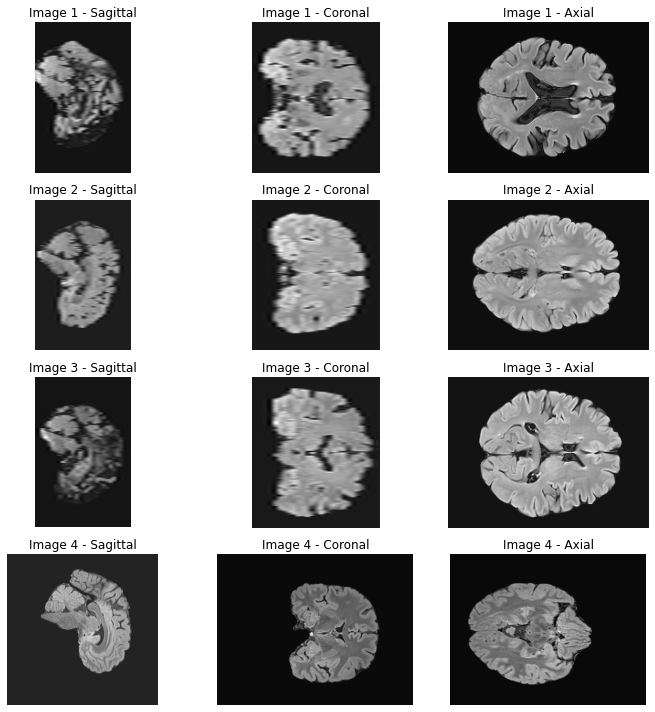

In [18]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(lemon_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# images
for image_path in tqdm(glob.glob(os.path.join(lemon_flair_resized_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)

    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (250, 250, 250)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(lemon_flair_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [03:49<00:00,  1.02s/it]


In [23]:
# images and masks
register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz", 
                    dataset_path=lemon_flair_resized_folder, 
                    output_path=lemon_flair_registered,
                    register_masks=False,
                    )


nifti_files ['/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032301_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032302_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032303_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032304_ses-01_acq-highres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032305_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032306_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032307_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032308_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032309_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/lemon_flair_resized/sub-032310_ses-01_acq-lowres_FLAIR.nii.gz', '/home/fehrdelt/

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [09:32<00:00,  2.54s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 432x288 with 0 Axes>

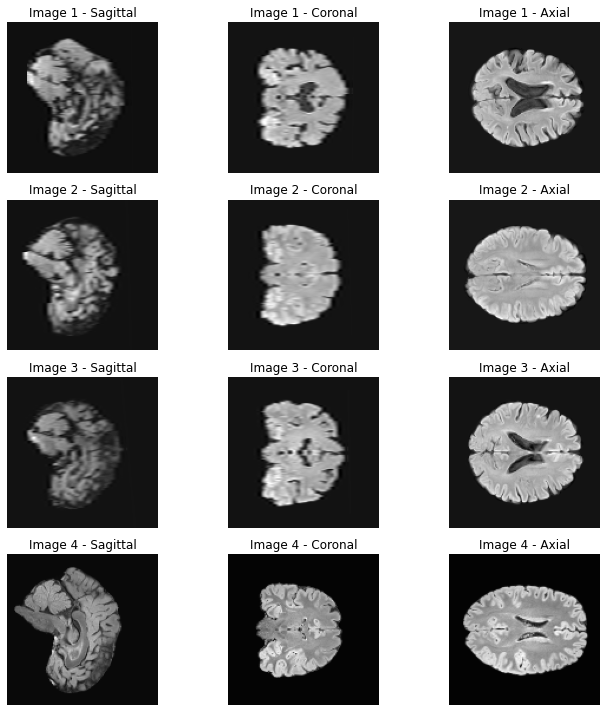

In [25]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(lemon_flair_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## OASIS
Original Size: (256, 256, 35)\
1. Resample it to 1mm3
Pad

1. Resize to (128, 128, 128)
2. Orient it like MNI
4. Register it to histogram matched MNI

In [8]:
oasis_flair_unprocessed_folder = ROOT_DIR+"/datasets/oasis_flair_skullstrip/"
os.makedirs(oasis_flair_unprocessed_folder, exist_ok=True)

oasis_flair_resized_folder = ROOT_DIR+"/datasets/oasis_flair_resized/"
os.makedirs(oasis_flair_resized_folder, exist_ok=True)

oasis_flair_registered = ROOT_DIR+"/datasets/final_flair_dataset_small/oasis_registered/"
os.makedirs(oasis_flair_registered, exist_ok=True)

Image 1 shape: (256, 256, 35)
Image 2 shape: (256, 256, 35)
Image 3 shape: (224, 256, 24)
Image 4 shape: (256, 256, 35)


<Figure size 640x480 with 0 Axes>

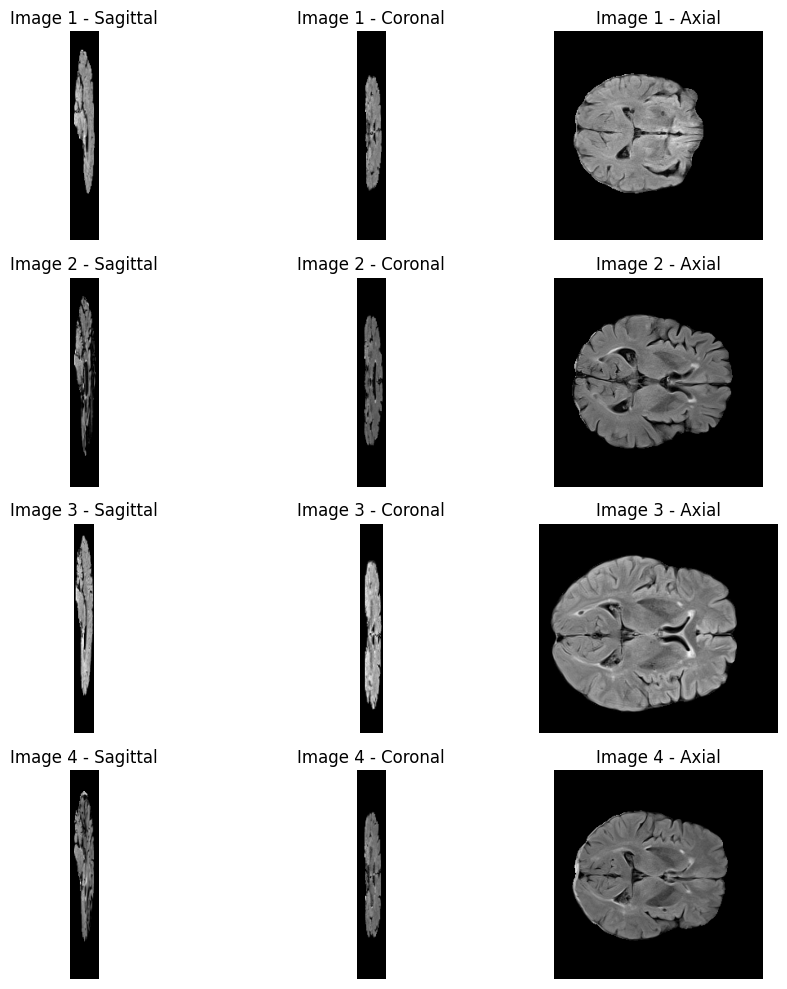

In [9]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(oasis_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# resample to 1mm3

for image_path in tqdm(glob.glob(os.path.join(oasis_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(oasis_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 744/744 [04:38<00:00,  2.68it/s]


Image 1 shape: (220, 220, 175)
Image 2 shape: (220, 220, 175)
Image 3 shape: (184, 210, 144)
Image 4 shape: (220, 220, 175)


<Figure size 640x480 with 0 Axes>

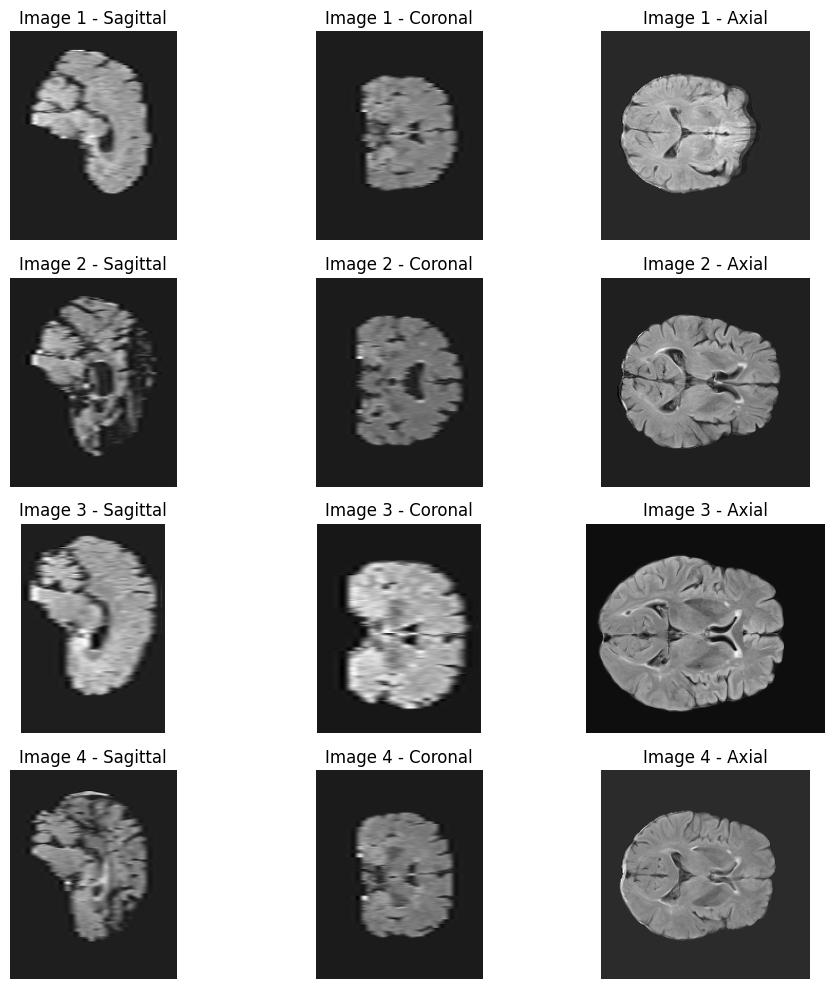

In [11]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(oasis_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# images
for image_path in tqdm(glob.glob(os.path.join(oasis_flair_resized_folder, "*.nii.gz"))):
    image = nib.load(image_path)
    image_data = image.get_fdata()
    #print(image_data.shape)

    original_shape = image_data.shape

    # Calculate padding for each dimension
    pad_width = []
    for orig, target in zip(original_shape, (220, 220, 220)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(oasis_flair_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 744/744 [19:51<00:00,  1.60s/it]


In [13]:
# images and masks
register_nifti_files(fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz", 
                    dataset_path=oasis_flair_resized_folder, 
                    output_path=oasis_flair_registered,
                    register_masks=False,
                    )


nifti_files ['/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30001_ses-d2430_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30002_ses-d2340_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30003_ses-d1631_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30003_ses-d2682_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30003_ses-d3731_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30004_ses-d2229_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30004_ses-d2232_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30004_ses-d3457_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30005_ses-d1274_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30005_ses-d2384_FLAIR.nii.gz', '/home/fehrdelt/bettik//datasets/oasis_flair_resized/sub-OAS30005_ses-d3453_F

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 744/744 [30:13<00:00,  2.44s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

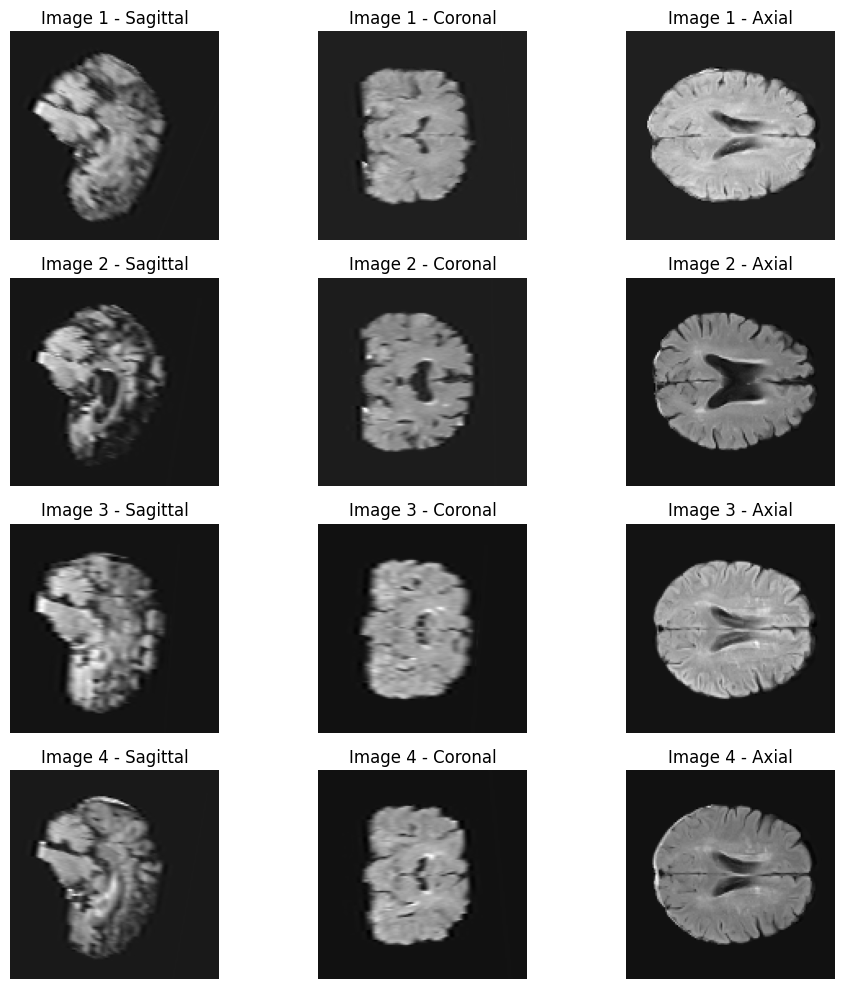

In [14]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(oasis_flair_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## BRATS FLAIR
Original Size: (240, 240, 155)\
1. Resample it to 1mm3
Pad

1. Resize to (128, 128, 128)
2. Orient it like MNI
4. Register it to histogram matched MNI

In [20]:
brats_flair_unprocessed_folder = ROOT_DIR+"/datasets/brats_flair/"
os.makedirs(brats_flair_unprocessed_folder, exist_ok=True)

brats_masks_folder = ROOT_DIR+"/datasets/brats_masks/"

brats_flair_resized_folder = ROOT_DIR+"/datasets/brats_flair_resized/"
os.makedirs(brats_flair_resized_folder, exist_ok=True)

brats_masks_resized = ROOT_DIR+"/datasets/brats_masks_resized/"
os.makedirs(brats_masks_resized, exist_ok=True)

brats_flair_registered = ROOT_DIR+"/datasets/final_flair_dataset_small/brats_registered/"
os.makedirs(brats_flair_registered, exist_ok=True)

brats_masks_registered = ROOT_DIR+"/datasets/final_flair_dataset_small/brats_masks_registered/"
os.makedirs(brats_masks_registered, exist_ok=True)

masks: collapse all masks into one (1 or 0)

Image 1 shape: (240, 240, 155)
Image 2 shape: (240, 240, 155)
Image 3 shape: (240, 240, 155)
Image 4 shape: (240, 240, 155)


<Figure size 640x480 with 0 Axes>

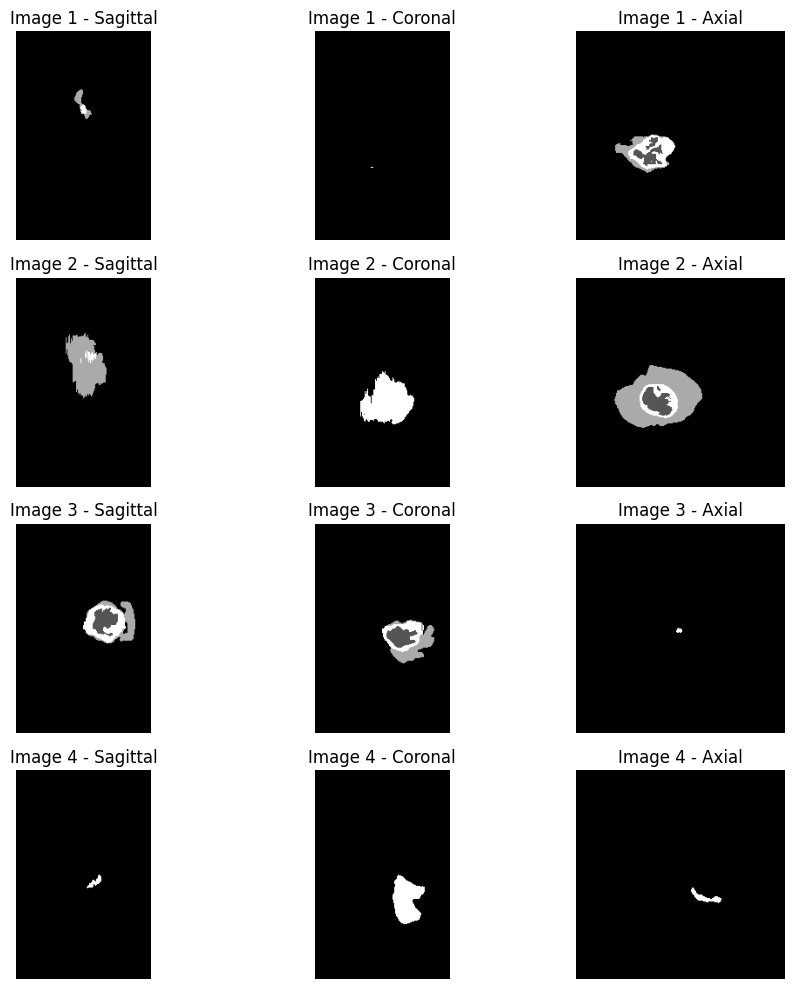

In [17]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(brats_masks_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
mask_paths = sorted(glob.glob(os.path.join(brats_masks_folder, "*.nii.gz")))[:4]

# Plot the masks

for i, mask_path in enumerate(mask_paths):
    mask = nib.load(mask_path).get_fdata()
    mask[mask != 0] = 1
    img = nib.load(mask_path)
    bin_mask_img = nib.Nifti1Image(mask.astype(np.uint8), img.affine, img.header)

    nib.save(bin_mask_img, os.path.join(brats_masks_folder, mask_path))

Image 1 shape: (240, 240, 155)
Image 2 shape: (240, 240, 155)
Image 3 shape: (240, 240, 155)
Image 4 shape: (240, 240, 155)


<Figure size 640x480 with 0 Axes>

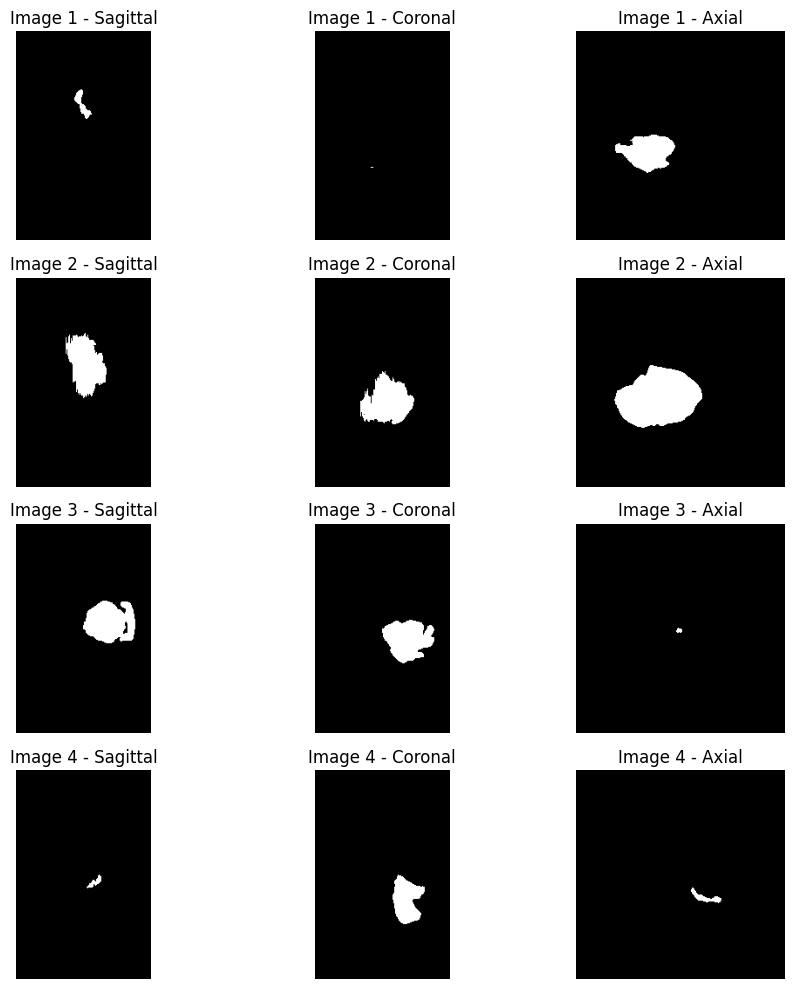

In [19]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(brats_masks_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Image 1 shape: (240, 240, 155)
Image 2 shape: (240, 240, 155)
Image 3 shape: (240, 240, 155)
Image 4 shape: (240, 240, 155)


<Figure size 640x480 with 0 Axes>

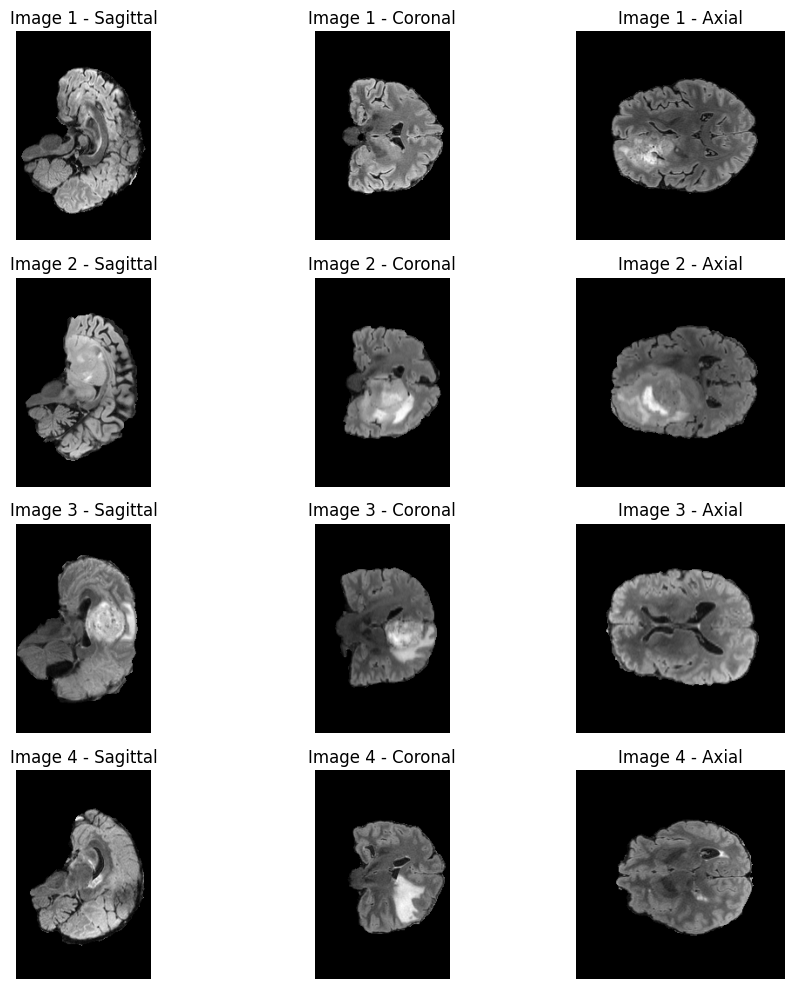

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(brats_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [7]:
os.makedirs(brats_flair_resized_folder, exist_ok=True)

for image_path in tqdm(glob.glob(os.path.join(brats_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(brats_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1251/1251 [17:40<00:00,  1.18it/s]


Image 1 shape: (240, 240, 155)
Image 2 shape: (240, 240, 155)
Image 3 shape: (240, 240, 155)
Image 4 shape: (240, 240, 155)


<Figure size 640x480 with 0 Axes>

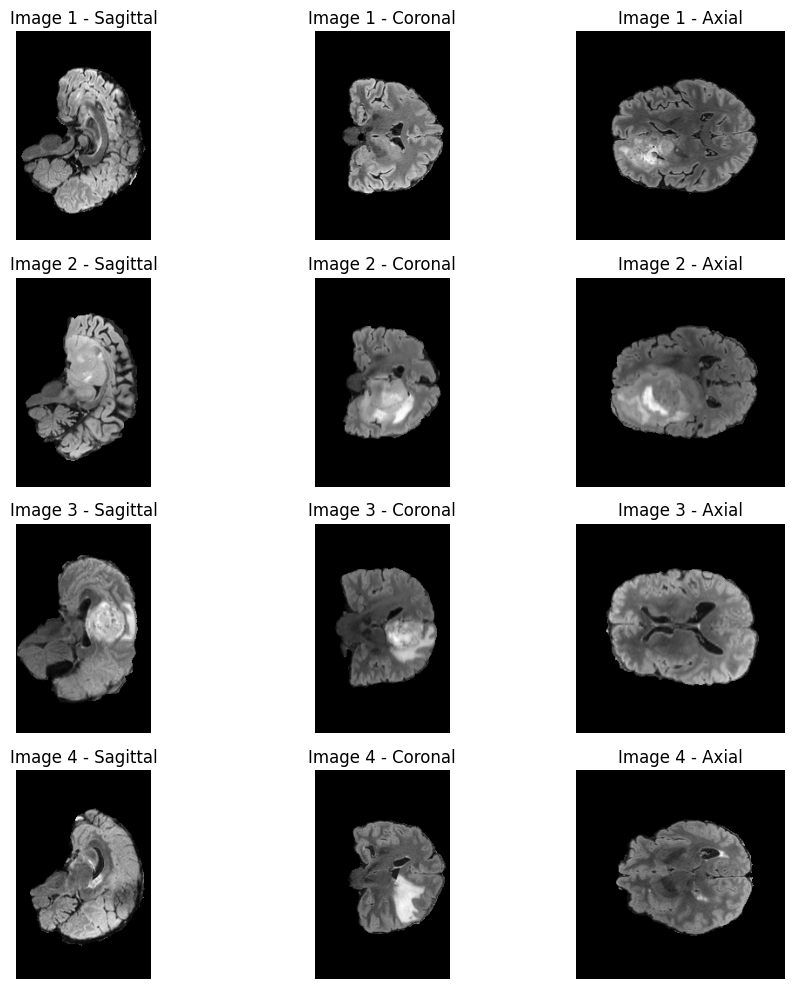

In [9]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(brats_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# images
for image_path, mask_path in tqdm(zip(glob.glob(os.path.join(brats_flair_resized_folder, "*.nii.gz")), glob.glob(os.path.join(brats_masks_folder, "*.nii.gz")))):
    image = nib.load(image_path)
    image_data = image.get_fdata()

    mask = nib.load(mask_path)
    mask_data = mask.get_fdata()
    

    # IMAGE Calculate padding for each dimension

    original_image_shape = image_data.shape

    pad_width = []
    for orig, target in zip(original_image_shape, (240, 240, 240)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    image_data = np.pad(image_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(brats_flair_resized_folder, os.path.basename(image_path))

    final_img = nib.Nifti1Image(image_data, image.affine, image.header)
    nib.save(final_img, output_path)


    # MASK Calculate padding for each dimension

    original_mask_shape = mask_data.shape

    pad_width = []
    for orig, target in zip(original_mask_shape, (240, 240, 240)):
        total_pad = max(target - orig, 0)
        before = total_pad // 2
        after = total_pad - before
        pad_width.append((before, after))

    # Pad the image
    mask_data = np.pad(mask_data, pad_width, mode='constant', constant_values=0)

    output_path = os.path.join(brats_masks_resized, os.path.basename(mask_path))

    final_img = nib.Nifti1Image(mask_data, mask.affine, mask.header)
    nib.save(final_img, output_path)


1251it [51:00,  2.45s/it]


Image 1 shape: (240, 240, 240)
Image 2 shape: (240, 240, 240)
Image 3 shape: (240, 240, 240)
Image 4 shape: (240, 240, 240)


<Figure size 640x480 with 0 Axes>

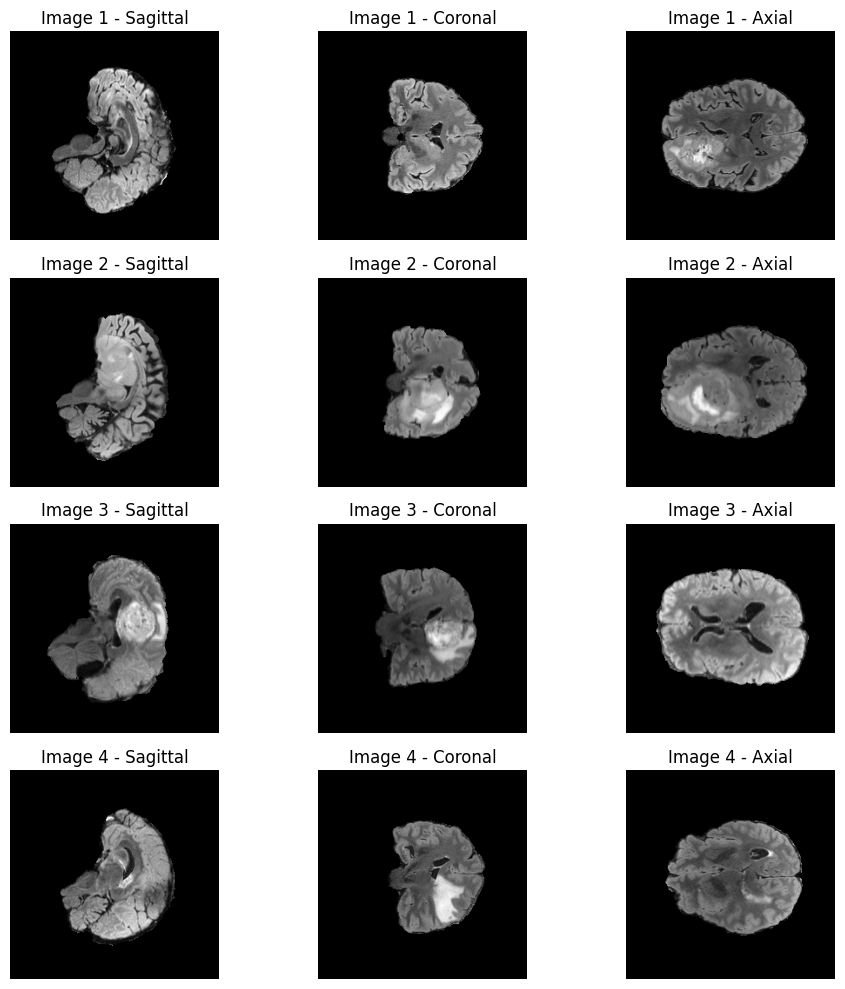

In [22]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(brats_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Image 1 shape: (240, 240, 240)
Image 2 shape: (240, 240, 240)
Image 3 shape: (240, 240, 240)
Image 4 shape: (240, 240, 240)


<Figure size 640x480 with 0 Axes>

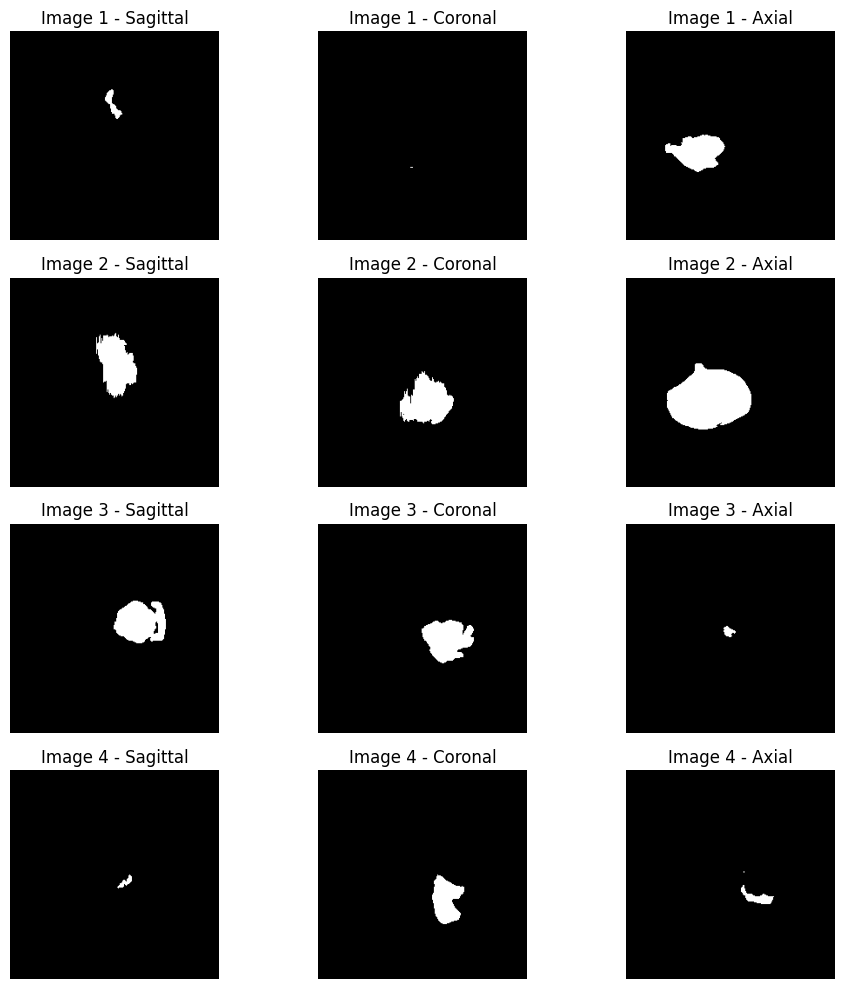

In [23]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(brats_masks_resized, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [26]:
# images and masks
register_nifti_files(
    fixed_reference=ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz", 
    dataset_path=brats_flair_resized_folder, 
    output_path=brats_flair_registered,
    register_masks=True,
    dataset_masks_path=brats_masks_resized,
    output_masks_path=brats_masks_registered,
    )

nifti_files ['/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00000-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00002-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00003-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00005-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00006-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00008-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00008-001-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00009-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00009-001-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00011-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_flair_resized/BraTS-GLI-00012-000-t2f.nii.gz', '/home/fehrdelt/bettik//datasets/brats_fl

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1251/1251 [1:08:36<00:00,  3.29s/it]


In [29]:
mask_paths = sorted(glob.glob(os.path.join(brats_masks_registered, "*.nii.gz")))

for mask_path in tqdm(mask_paths):
    mask = nib.load(mask_path).get_fdata()
    mask[mask < 1e-3] = 0.0
    mask[mask >= 1e-2] = 1.0
    img = nib.load(mask_path)
    bin_mask_img = nib.Nifti1Image(mask.astype(np.uint8), img.affine, img.header)

    nib.save(bin_mask_img, os.path.join(brats_masks_registered, os.path.basename(mask_path)))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1251/1251 [02:54<00:00,  7.16it/s]


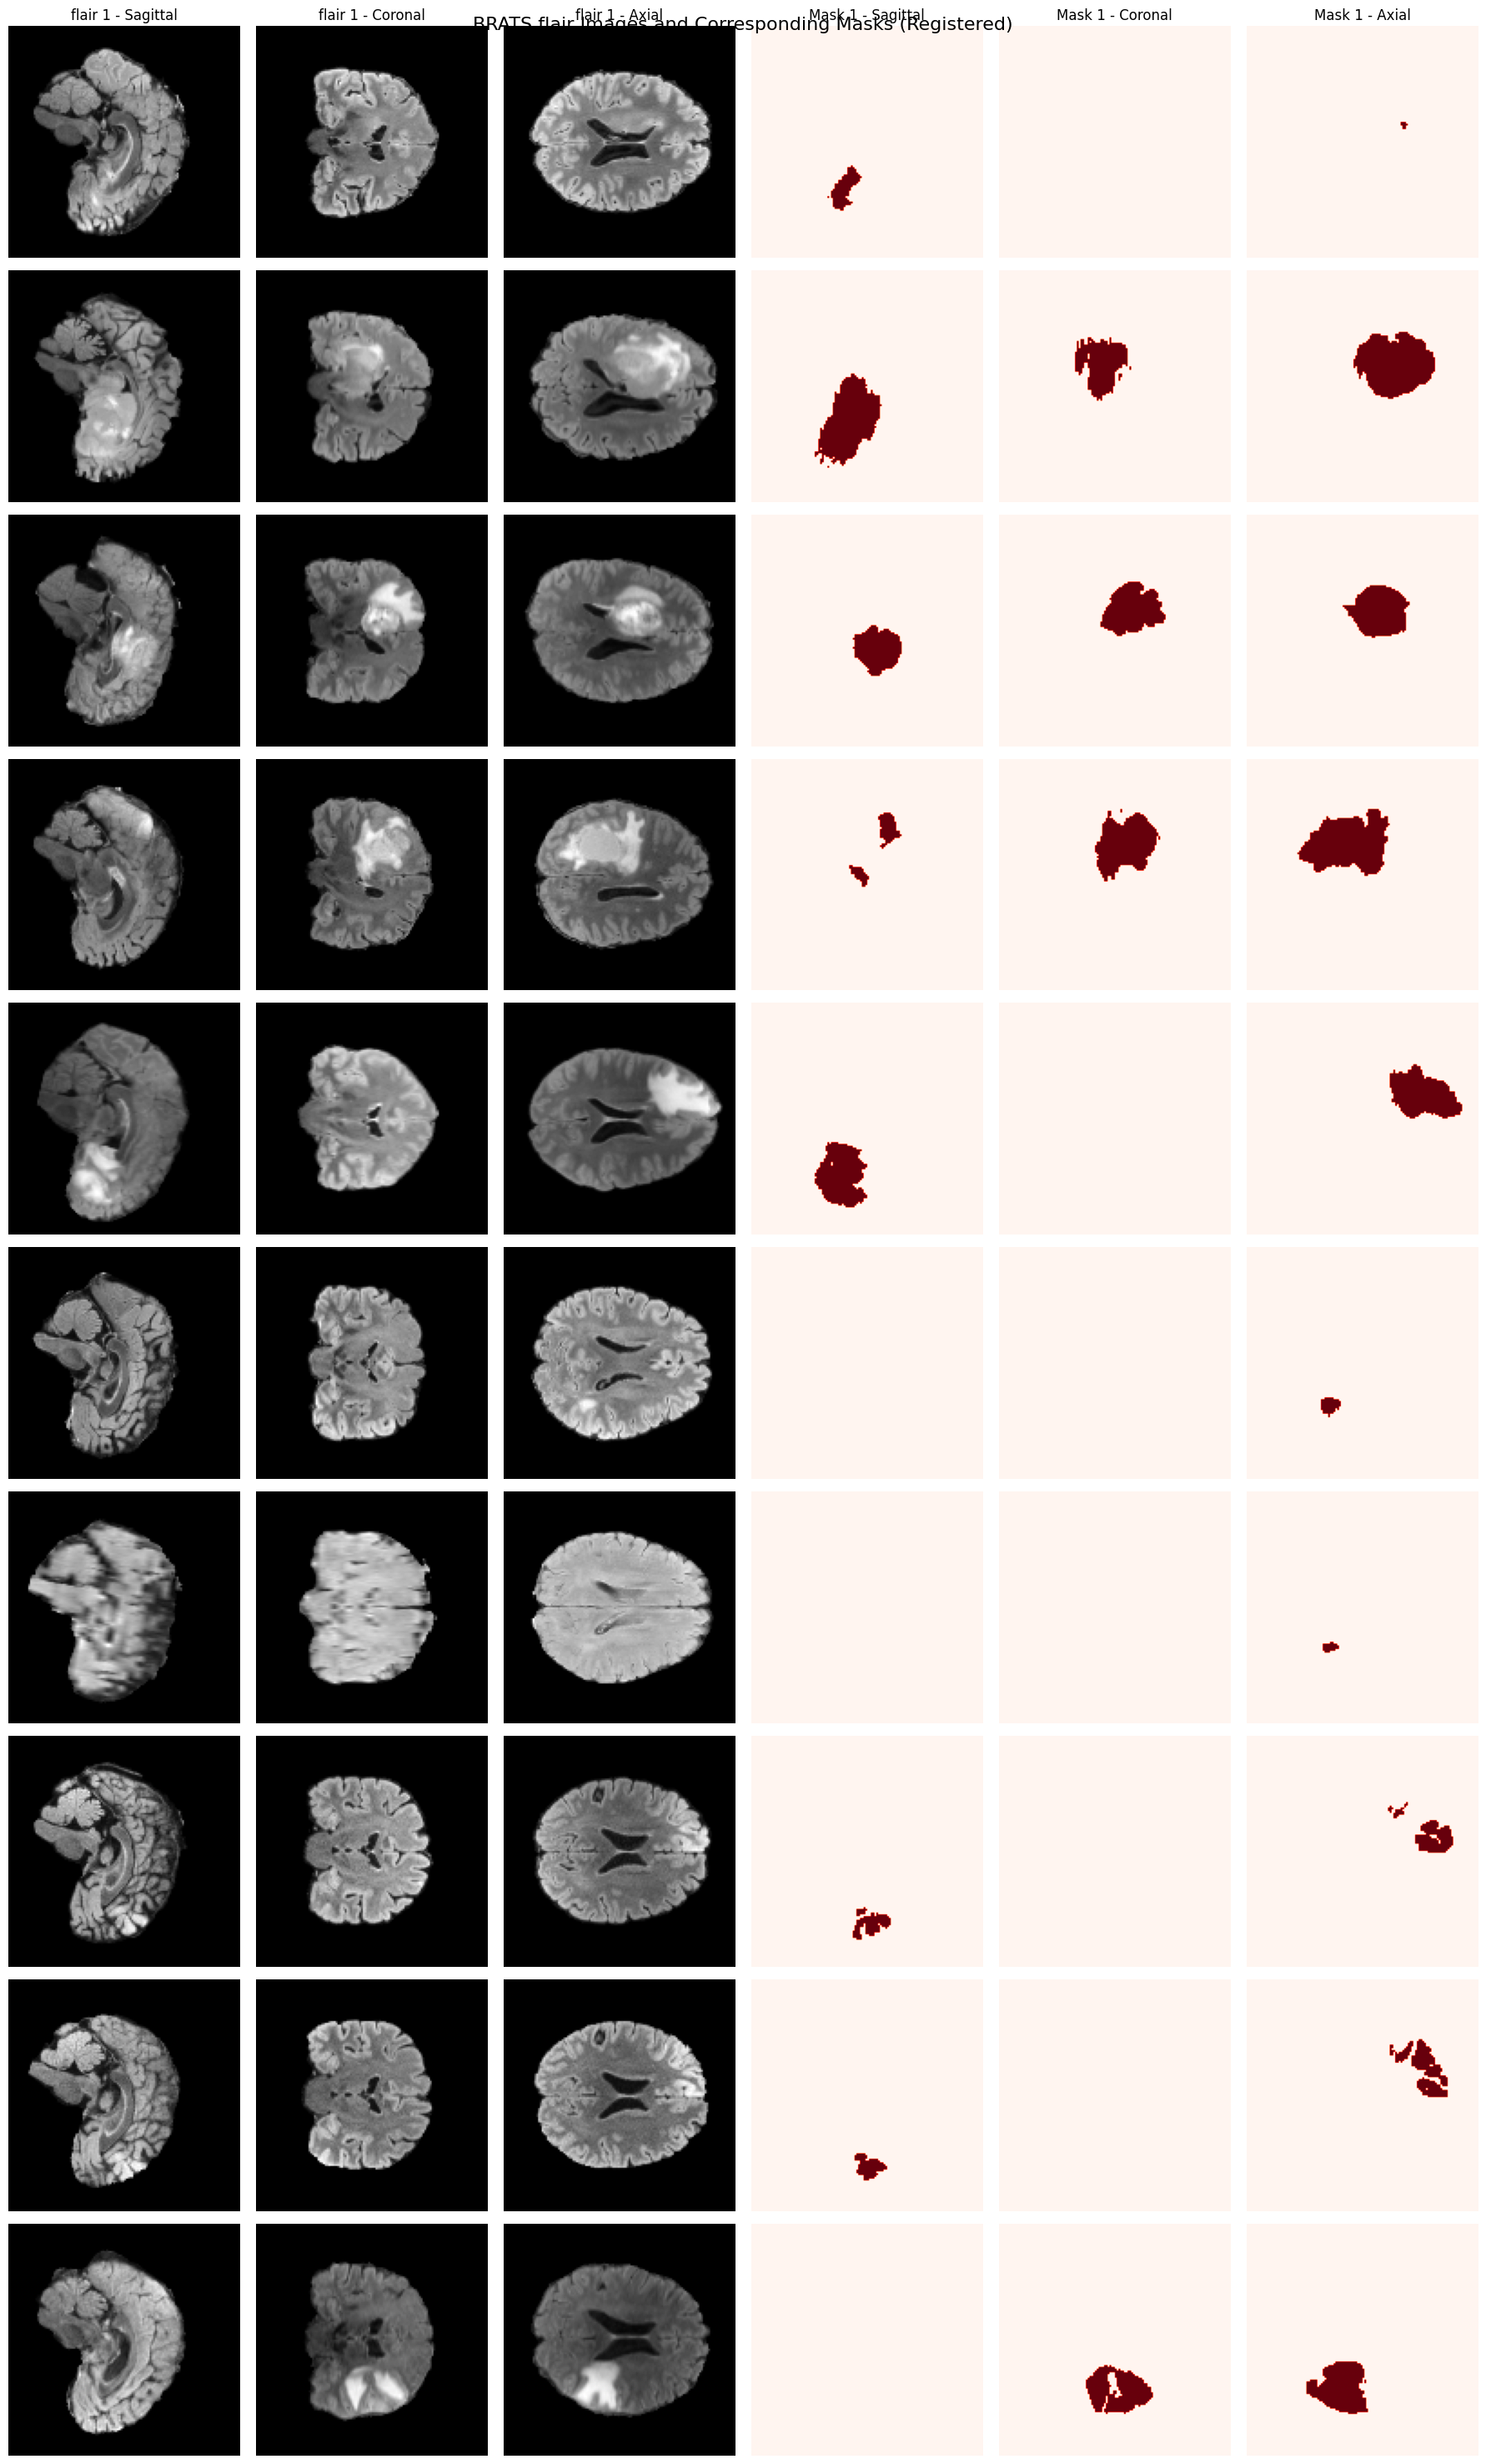

In [30]:
# Get sorted file paths for both flair images and masks
flair_paths = sorted(glob.glob(os.path.join(brats_flair_registered, "*.nii.gz")))
mask_paths = sorted(glob.glob(os.path.join(brats_masks_registered, "*.nii.gz")))

# Take first 10 pairs for visualization
num_pairs = min(10, len(flair_paths), len(mask_paths))

fig, axes = plt.subplots(num_pairs, 6, figsize=(18, 3*num_pairs))
plt.suptitle("BRATS flair Images and Corresponding Masks (Registered)", fontsize=16)

for i in range(num_pairs):
    # Load flair image and mask
    flair_img = nib.load(flair_paths[i]).get_fdata()
    mask_img = nib.load(mask_paths[i]).get_fdata()
    #print(np.unique(mask_img))
    
    # Get middle slices
    mid_slice = flair_img.shape[2] // 2
    flair_axial = flair_img[:, :, mid_slice]
    mask_axial = mask_img[:, :, mid_slice]
    
    mid_slice_sag = flair_img.shape[0] // 2
    flair_sagittal = flair_img[mid_slice_sag, :, :]
    mask_sagittal = mask_img[mid_slice_sag, :, :]
    
    mid_slice_cor = flair_img.shape[1] // 2
    flair_coronal = flair_img[:, mid_slice_cor, :]
    mask_coronal = mask_img[:, mid_slice_cor, :]
    
    # Plot flair sagittal
    axes[i, 0].imshow(flair_sagittal, cmap="gray")
    axes[i, 0].set_title(f"flair {i+1} - Sagittal" if i == 0 else "")
    axes[i, 0].axis("off")
    
    # Plot flair coronal
    axes[i, 1].imshow(flair_coronal, cmap="gray")
    axes[i, 1].set_title(f"flair {i+1} - Coronal" if i == 0 else "")
    axes[i, 1].axis("off")
    
    # Plot flair axial
    axes[i, 2].imshow(flair_axial, cmap="gray")
    axes[i, 2].set_title(f"flair {i+1} - Axial" if i == 0 else "")
    axes[i, 2].axis("off")
    
    # Plot Mask sagittal
    axes[i, 3].imshow(mask_sagittal, cmap="Reds")
    axes[i, 3].set_title(f"Mask {i+1} - Sagittal" if i == 0 else "")
    axes[i, 3].axis("off")
    
    # Plot Mask coronal
    axes[i, 4].imshow(mask_coronal, cmap="Reds")
    axes[i, 4].set_title(f"Mask {i+1} - Coronal" if i == 0 else "")
    axes[i, 4].axis("off")
    
    # Plot Mask axial
    axes[i, 5].imshow(mask_axial, cmap="Reds")
    axes[i, 5].set_title(f"Mask {i+1} - Axial" if i == 0 else "")
    axes[i, 5].axis("off")

plt.tight_layout()
plt.show()

## AINI-Stroke AIT FLAIR
Original Size: (280, 280, 36)\
1. Resample it to 1mm3
Pad

1. Resize to (128, 128, 128)
2. Orient it like MNI
4. Register it to histogram matched MNI

In [50]:
aini_stroke_flair_ait_unprocessed_folder = ROOT_DIR+"/datasets/aini_stroke_flair_ait_extracted_brain/"
os.makedirs(aini_stroke_flair_ait_unprocessed_folder, exist_ok=True)

aini_stroke_flair_ait_resized_folder = ROOT_DIR+"/datasets/aini_stroke_flair_ait_resized/"
os.makedirs(aini_stroke_flair_ait_resized_folder, exist_ok=True)

aini_stroke_flair_ait_registered = ROOT_DIR+"/datasets/aini_stroke_flair_ait_registered/"
os.makedirs(aini_stroke_flair_ait_registered, exist_ok=True)

Image 1 shape: (256, 256, 35)
Image 2 shape: (256, 256, 35)
Image 3 shape: (256, 256, 35)
Image 4 shape: (256, 256, 35)


<Figure size 432x288 with 0 Axes>

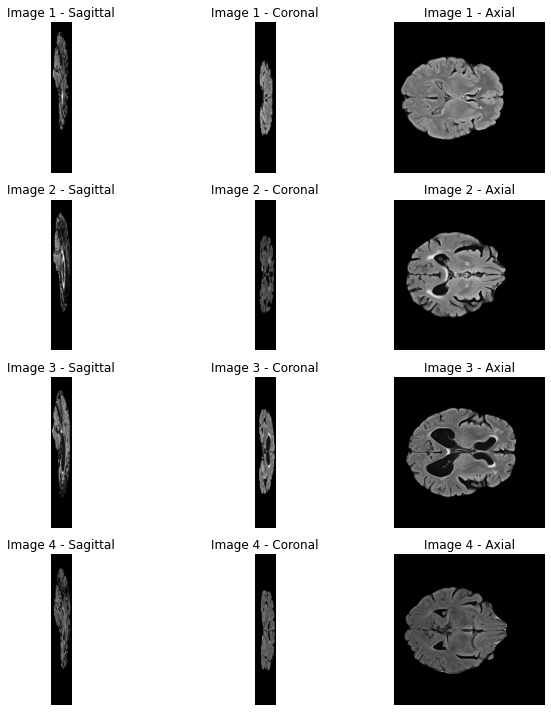

In [51]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(aini_stroke_flair_ait_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()